# SpatialProp LOO Evaluation

Mirrors `perturb_loo.ipynb` but uses the spatial-prop GNN instead of cellina.

**Experiment logic:**
- Hold out `holdout_celltype` cells from the CRC region during GNN training
- At inference, the GNN predicts those cells' expression from their *actual* CRC neighbors
- This CRC-neighbor prediction is the analog of cellina's spatial-context swap
- We measure how well the predicted CRC expression matches the real holdout cells using `compute_cf_logfc`

**Metrics (same as perturb_loo.ipynb):**
- `ref_expr` = GNN prediction for holdout cells *in REF* (from REF neighbors)
- `pert_expr` = GNN prediction for holdout cells *in CRC* (from CRC neighbors) ← the "perturbation"
- `cf_expr`  = real expression for holdout cells in CRC ← ground truth

In [ ]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import os
import sys
# sys.path.append('../../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import pearsonr

from spatial_gnn.api.perturbation_api import (
    train_perturbation_model,
    create_perturbation_input_matrix,
    predict_perturbation_effects
)
from spatial_gnn.utils.plot_utils import (
    plot_loss_curves,
    plot_celltype_performance,
    plot_celltypes_in_section,
    plot_propagation_results_for_gene_set
)

from perturb_utils import load_crc_slide, split_indices, compute_cf_logfc

plt.rcParams['figure.dpi'] = 100

/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/libpyg.so: undefined symbol: _ZN5torch8autograd12VariableInfoC1ERKN2at6TensorE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred whi

In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id         = 242
labels_key       = 'coarse_type'
domains_key      = 'typ'
holdout_celltype = 'T_cell'   # change to 'Fibroblast', 'Myeloid', etc.
top_n            = 100        # genes for logFC metric evaluation
exp_name         = f'crc_loo_{holdout_celltype}'
out_dir          = f'./output/{exp_name}'

ref_label = f'{slide_id}_REF'
crc_label = f'{slide_id}_CRC'
top_n_perturb    = 50

## 1. Data Loading & Column Mapping

spatial-prop requires `obs["celltype"]`, `obs["mouse_id"]`, and optionally `obs["region"]`.

In [3]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)

adata.obs['celltype'] = adata.obs[labels_key]
adata.obs['mouse_id'] = str(slide_id)
adata.obs['region']   = adata.obs[domains_key]

print(adata)
print(f"\nCell types: {sorted(adata.obs['celltype'].unique())}")
print(f"Regions:    {sorted(adata.obs['region'].unique())}")

AnnData object with n_obs × n_vars = 420694 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [4]:
adata.X.max()

np.float64(1079.0)

> **Caveat — coordinate units**: `obsm['spatial']` contains CosMx global pixel coordinates
> (~0.12 µm/px). spatial-prop's Delaunay graph pruning uses a radius cutoff hardcoded at
> 200 in `spatial_dataset.py`. If that unit is µm, 200 µm ÷ 0.12 µm/px ≈ 1667 px — meaning
> the cutoff of 200 would include only cells within ~24 µm, which may be too tight.
> Check whether `train_perturbation_model` accepts a `radius_cutoff` kwarg and set it
> accordingly (e.g. `"radius_cutoff": 1667`).

## 2. Holdout Split → adata_train / adata_test

In [5]:
train_idx, val_idx, test_idx = split_indices(
    adata, holdout_celltype=holdout_celltype,
    labels_key=labels_key, domains_key=domains_key,
)
# adata.obs['is_holdout'] is now True for holdout_celltype cells in any CRC region

print(f"train: {len(train_idx):,}  val: {len(val_idx):,}  holdout (CRC): {len(test_idx):,}")
print(f"Held-out cells: {adata.obs['is_holdout'].sum()} {holdout_celltype} in CRC region")

adata_train = adata[~adata.obs['is_holdout']].copy()   # holdout CRC cells excluded
adata_test  = adata.copy()                              # full slide for inference

os.makedirs(out_dir, exist_ok=True)
train_path = f'{out_dir}/adata_train.h5ad'
test_path  = f'{out_dir}/adata_test.h5ad'
adata_train.write(train_path)
adata_test.write(test_path)

print(f"\nSaved: {train_path}")
print(f"Saved: {test_path}")

train: 375,705  val: 41,744  holdout (CRC): 3,245
Held-out cells: 3245 T_cell in CRC region

Saved: ./output/crc_loo_T_cell/adata_train.h5ad
Saved: ./output/crc_loo_T_cell/adata_test.h5ad


## 3. Train SpatialProp GNN

> **Caveat — in-sample test loss**: `train_ids == test_ids` (single slide). The test loss
> reported during training reflects in-sample fit, not generalisation to the holdout cells.
> Real validation happens in Section 4 below.

In [6]:
training_args = {
    'dataset':             f'crc_{slide_id}_{holdout_celltype}',
    'file_path':           train_path,
    'train_ids':           [str(slide_id)],
    'test_ids':            [str(slide_id)],   # same — in-sample only
    'exp_name':            exp_name,
    'k_hop':               2,
    'augment_hop':         2,
    'center_celltypes':    'all',
    'node_feature':        'expression',
    'inject_feature':      'none',
    'learning_rate':       1e-4,
    'loss':                'weightedl1',
    'epochs':              30,
    'normalize_total':     True,
    'num_cells_per_ct_id': 100,
    'predict_celltype':    False,
    'pool':                'center',
    'do_eval':             False,
    'device':              'cuda' if torch.cuda.is_available() else 'cpu',
    # Uncomment and set if train_perturbation_model accepts radius_cutoff:
    # 'radius_cutoff': 1667,   # ~200 µm at 0.12 µm/px
}

test_loader, gene_names, (model, model_config, trained_model_path) = \
    train_perturbation_model(**training_args)

print(f"\nModel saved to: {trained_model_path}")

Training new perturbation model from scratch...
Model will be saved to: ./output/crc_loo_T_cell/crc_242_T_cell_expression_2hop_2augment_expression_none/weightedl1_1en04
Training on device: cuda
Dataset already exists at:  ./data/gnn_datasets/crc_242_T_cell_expression_100per_2hop_2C0aug_200delaunay_expressionFeat_all_NoneInject_subset_242/test
Finished processing test dataset
Dataset already exists at:  ./data/gnn_datasets/crc_242_T_cell_expression_100per_2hop_2C0aug_200delaunay_expressionFeat_all_NoneInject_subset_242/train
Finished processing train dataset


100%|██████████| 34/34 [00:07<00:00,  4.75it/s]
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
100%|██████████| 34/34 [00:06<00:00,  4.95it/s]

Train samples: 16746
Test samples: 16746


Expression model initialized on cuda
Starting GNN training for 30 epochs...
 Epoch: 001, Train WL1: 10.1116, Test WL1: 10.1118, Test Spearman: 0.0061
 Epoch: 002, Train WL1: 10.0802, Test WL1: 10.0803, Test Spearman: 0.0121
 Epoch: 003, Train WL1: 10.0580, Test WL1: 10.0581, Test Spearman: 0.0219
 Epoch: 004, Train WL1: 10.0413, Test WL1: 10.0414, Test Spearman: 0.0366
 Epoch: 005, Train WL1: 10.0280, Test WL1: 10.0281, Test Spearman: 0.0541
 Epoch: 006, Train WL1: 10.0181, Test WL1: 10.0182, Test Spearman: 0.0704
 Epoch: 007, Train WL1: 10.0117, Test WL1: 10.0118, Test Spearman: 0.0815
 Epoch: 008, Train WL1: 10.0070, Test WL1: 10.0070, Test Spearman: 0.0895
 Epoch: 009, Train WL1: 10.0037, Test WL1: 10.0038, Test Spearman: 0.0945
 Epoch: 010, Train WL1: 10.0011, Test WL1: 10.0012, Test Spearman: 0.0980
 Epoch: 011, Train WL1: 9.9988, Test WL1: 9.9989, Test Spearman: 0.1007
 Epoch: 012, Train WL1: 9.9966, Test WL1: 9.9966, Test Spearman: 0.1025
 Epoch: 013, Train WL1: 9.9941, Test WL1

In [7]:
import scanpy as sc
from spatial_gnn.datasets.spatial_dataset import SpatialAgingCellDataset
from spatial_gnn.utils.dataset_utils import load_model_from_path, create_dataloader_from_dataset
from spatial_gnn.models.inference import predict


def predict_for_holdout(adata_path, model_path, exp_name,
                        center_celltypes, use_ids=None,
                        device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Like predict_perturbation_effects but restricts center nodes to
    center_celltypes (instead of whole_tissue=True which uses all 420k cells).

    Neighbourhoods in the Delaunay graph still include ALL cell types, so
    context is preserved. Only the set of cells that generate a prediction
    subgraph is reduced — from 420k (all cells) to ~30k (holdout type only).

    whole_tissue=False  + num_cells_per_ct_id=100_000 routes through the
    per-cell-type sampling branch in _process_single_sample, selecting
    min(100_000, n_cells_of_type) ≈ all cells of that type.
    """
    test_adata = sc.read_h5ad(adata_path)
    model, model_config = load_model_from_path(model_path, device)
    celltypes_to_index = model_config['celltypes_to_index']

    shared_kwargs = dict(
        subfolder_name='predict_holdout',
        dataset_prefix=exp_name,
        target='expression',
        k_hop=2,
        augment_hop=0,            # no augmentation at inference
        node_feature='expression',
        inject_feature=None,
        num_cells_per_ct_id=100_000,   # effectively "all" for the selected type
        center_celltypes=center_celltypes,
        whole_tissue=False,       # must be False for center_celltypes to be respected
        use_ids=use_ids,
        raw_filepaths=[adata_path],
        celltypes_to_index=celltypes_to_index,
        normalize_total=True,
    )

    test_dataset = SpatialAgingCellDataset(**shared_kwargs)
    test_dataset.process()

    perturbed_test_dataset = SpatialAgingCellDataset(
        **shared_kwargs,
        perturbation_mask_key='perturbed_input',
        use_perturbed_expression=True,
    )
    perturbed_test_dataset.process()

    loader_kwargs = dict(batch_size=512, shuffle=False, num_workers=4,
                         pin_memory=True, persistent_workers=True)
    _, test_loader = create_dataloader_from_dataset(test_dataset, **loader_kwargs)
    _, pert_loader = create_dataloader_from_dataset(perturbed_test_dataset, **loader_kwargs)

    return predict(
        model=model, adata=test_adata,
        dataloader=test_loader, perturbed_dataloader=pert_loader,
        use_ids=use_ids, temper_method='distribution_renormalize', device=device,
    )

We can also plot performance of the model by cell type on the held-out mouse. Here we show correlation metrics for the masked center cell expression prediction task used during training.

In [8]:
# plot_celltype_performance(model_dir)

In [9]:
import decoupler as dc
import scanpy as sc

pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col=domains_key,
    groups_col=labels_key,
    mode='sum',
    layer='counts',
)
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)

ref_label = f'{slide_id}_REF'
crc_label = f'{slide_id}_CRC'

cell_types = [
    ct for ct in pdata.obs[labels_key].unique()
    if ((pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)).any()
    and ((pdata.obs[domains_key] == crc_label) & (pdata.obs[labels_key] == ct)).any()
]

domain_logfc_df = pd.concat(
    [
        pd.Series(
            (
                pdata[(pdata.obs[domains_key] == crc_label) & (pdata.obs[labels_key] == ct)].X
                - pdata[(pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)].X
            ).flatten(),
            index=pdata.var_names,
            name=ct,
        )
        for ct in cell_types
    ],
    axis=1,
).T

print(f"logFC matrix: {domain_logfc_df.shape}  (cell types × genes)")
domain_logfc_df.head()

logFC matrix: (8, 3000)  (cell types × genes)


,DDX60L,SH3TC1,RGS7,STAP1,G0S2,PTPRR,ATP13A4,ROS1,MSX2,PSMG4,...,GPR15,ARHGEF4,FAM163A,ACTRT3,RCAN1,PIM1,LAPTM5,APOL1,CXCL5,H3C12
Endothelial,-0.577904,-0.356066,-0.529708,-0.274982,0.112245,-0.754418,-0.121465,-0.359818,-0.625385,-0.023726,...,-0.320390,-0.317067,-0.267649,-0.528553,-0.154368,0.049475,0.689768,-0.026805,-0.527561,0.078071
Epithelial,-0.413618,-0.015889,-0.234075,-0.228569,-0.067379,0.430408,-0.418969,-0.527748,-0.111391,0.041345,...,-0.241690,-0.210079,-0.208957,-0.338790,-0.301606,0.146697,-0.182228,0.670551,-0.441461,0.311994
Fibroblast,-0.453132,-0.337090,-0.372903,-0.400685,-0.452654,-0.387643,-0.275183,-0.488787,-0.477614,-0.471474,...,-0.684369,-0.410710,-0.529076,-0.636689,-0.362732,0.255989,0.433973,0.232396,-0.300495,-0.224854
Mast_cell,-0.266114,0.755196,0.020974,-0.769114,-0.307306,-0.154589,0.081252,-0.778805,-0.554431,-0.162174,...,-0.098884,-0.295956,-0.130437,-0.079095,-0.136951,0.642027,1.396774,0.113619,-0.400048,-0.341742
Myeloid,-0.123918,-0.265512,-0.187573,-0.414656,-0.213312,-0.321049,-0.069781,-0.511003,-0.421269,-0.557012,...,-0.323155,-0.156370,-0.456663,-0.120254,0.016705,0.205870,0.573811,0.080854,0.067158,-0.016721


In [10]:

perturbation_dict = {}
for ct in domain_logfc_df.index:
    s = domain_logfc_df.loc[ct]
    top_genes = s.abs().nlargest(top_n_perturb).index.tolist()
    perturbation_dict[ct] = s[top_genes].to_dict()

In [11]:
perturbed_path = f'{out_dir}/adata_test_perturbed.h5ad'
create_perturbation_input_matrix(
    adata_test, perturbation_dict,
    save_path=perturbed_path,
    normalize_total=True,
)

adata_result = predict_for_holdout(
    perturbed_path,
    trained_model_path,
    exp_name,
    center_celltypes=[holdout_celltype],
    use_ids=[str(slide_id)],
)

print('Layers available:', list(adata_result.layers.keys()))
print('Result shape:', adata_result.shape)

Applying perturbations to 7506 cells of type 'Endothelial'
  - Gene 'CLU': multiplier = -2.2809000347552573
  - Gene 'COL4A1': multiplier = 2.0675633399610573
  - Gene 'IGFBP3': multiplier = 2.0550703562322634
  - Gene 'ACKR1': multiplier = -1.9763310983312452
  - Gene 'COL1A1': multiplier = 1.9216237448767912
  - Gene 'SPARC': multiplier = 1.8214454156884043
  - Gene 'IGHA1': multiplier = -1.788989530925425
  - Gene 'FOS': multiplier = -1.7616611957583075
  - Gene 'COL4A2': multiplier = 1.667985552531786
  - Gene 'NID1': multiplier = 1.6354716895150314
  - Gene 'FN1': multiplier = 1.6039986534070803
  - Gene 'CALD1': multiplier = 1.5631631174148248
  - Gene 'MMP2': multiplier = 1.5567346430488316
  - Gene 'COL1A2': multiplier = 1.5509812781512209
  - Gene 'ESM1': multiplier = 1.5394672921268093
  - Gene 'FSTL1': multiplier = 1.5379758610664505
  - Gene 'H3C2': multiplier = 1.5125223925878166
  - Gene 'IGFBP5': multiplier = 1.4841588316713943
  - Gene 'OLFM4': multiplier = -1.434195771

/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Processing 1 samples
Using sequential processing for 1 samples


  0%|          | 0/1 [00:00<?, ?it/s]

Sample 1: 242 (PID: 2217177)


...

Total subgraphs created: 17908


100%|██████████| 36/36 [00:03<00:00, 10.47it/s]
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
100%|██████████| 36/36 [00:03<00:00,  9.50it/s]


Starting prediction for 420694 cells, 3000 genes


Predicting (unperturbed & perturbed) with tempering...:   0%|          | 0/35 [00:00<?, ?it/s]/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/spatial_gnn/models/inference.py:123: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_expn_batch = torch.tensor(
Predicting (unperturbed & perturbed) with tempering...: 100%|██████████| 35/35 [00:02<00:00, 12.35it/s]
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/spatial_gnn/models/inference.py:150: ImplicitModificationWarning: Setting element `.layers['predicted_unperturbed']` of view, initializing view as actual.
  adata.layers["predicted_unperturbed"] = unperturbed_prediction_matrix


Predicted on 17908 cells
Applied tempering with method 'distribution_renormalize' (batch-wise)
Layers available: ['counts', 'predicted_unperturbed', 'predicted_perturbed', 'predicted_tempered']
Result shape: (420694, 3000)


## 5. logFC Metrics — Mirroring perturb_loo.ipynb`

In [12]:
mask_holdout_crc = (
    (adata_result.obs['celltype'] == holdout_celltype) &
    (adata_result.obs['region']   == crc_label)
)
mask_holdout_ref = (
    (adata_result.obs['celltype'] == holdout_celltype) &
    (adata_result.obs['region']   == ref_label)
)


In [13]:
def _total_normalize(X):
    X = X.toarray() if hasattr(X, 'toarray') else np.asarray(X, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    X = np.clip(X, 0, None)
    X = X / np.maximum(X.sum(axis=1, keepdims=True), 1e-6)
    X = X * 1e4
    return X

    
# ref_expr  = _total_normalize(np.expm1(adata_result[mask_holdout_ref].layers['predicted_unperturbed']))
ref_expr = _total_normalize(adata_result[mask_holdout_ref].X)
pert_expr  = _total_normalize(np.expm1(adata_result[mask_holdout_crc].layers['predicted_tempered']))
obs_expr = _total_normalize(adata_result[mask_holdout_crc].X)


ref_expr = ref_expr.toarray() if hasattr(ref_expr, 'toarray') else ref_expr
pert_expr = pert_expr.toarray() if hasattr(pert_expr, 'toarray') else pert_expr
obs_expr = obs_expr.toarray() if hasattr(obs_expr, 'toarray') else obs_expr

stats = compute_cf_logfc(
    ref_expr=ref_expr, pert_expr=pert_expr, obs_expr=obs_expr,
    top_n=top_n,
    gene_names=adata_result.var_names.tolist(),
)

print(f"Pearson r  = {stats['pearson_r']:.3f}")
print(f"Spearman ρ = {stats['spearman_r']:.3f}")
print(f"Precision  = {stats['precision']:.2f}")
print(f"Edistance  = {stats['edistance']:.3f}")

/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/anndata/_core/views.py:145: RuntimeWarning: overflow encountered in expm1
  results = super().__array_ufunc__(
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Pearson r  = 0.694
Spearman ρ = 0.690
Precision  = 0.28
Edistance  = 2410.379


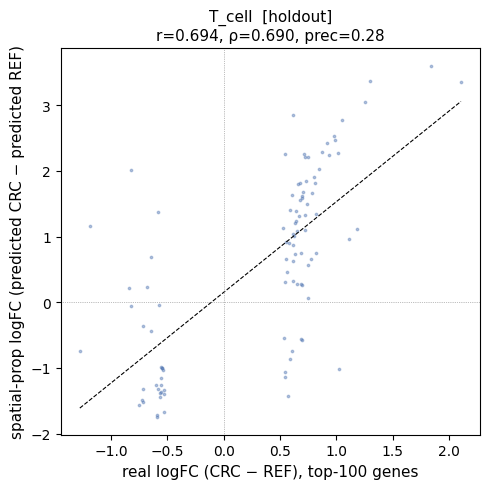

: 

In [ ]:
real = stats['real_logfc']
pred = stats['pred_logfc']
mask = stats['top_n_mask']
if mask is not None:
    real, pred = real[mask], pred[mask]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(real, pred, s=3, alpha=0.4, color='#4C72B0')

m, b = np.polyfit(real, pred, 1)
x_lo, x_hi = real.min(), real.max()
ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], 'k--', lw=0.8)
ax.axhline(0, color='grey', lw=0.5, ls=':')
ax.axvline(0, color='grey', lw=0.5, ls=':')

ax.set_xlabel(f'real logFC (CRC − REF), top-{top_n} genes', fontsize=11)
ax.set_ylabel('spatial-prop logFC (predicted CRC − predicted REF)', fontsize=11)
ax.set_title(
    f"{holdout_celltype}  [holdout]\n"
    f"r={stats['pearson_r']:.3f}, ρ={stats['spearman_r']:.3f}, prec={stats['precision']:.2f}",
    fontsize=11,
)

plt.tight_layout()
plt.show()